# SQLite

Just likw CSV, sqlite is another file format which a data scientist need to deal with very frequetly.

1) It is a relational databse management system based on the SQL language -> a software library 

2) It is a self-contained, serverless and requires zero-configurations -> easy to setup 

3) It is very fast and lightweight and the entire database is stored in a single disk file. -> easy to use and share wih others

4) The Lite in SQLite means light weight in terms of setup ,database administration and required resource \

5) It is used in a lot of applications as internal data storage 

So it's a DB engine making easy to store relational data many programming language provides support for sqlite and python is not exception .

In python there are many libraries with which we can interact with a sqlite data like sqlalchemy and sqlite3. we will use sqlite3 since it comes by default with python.

To visualize data better instal DB browser : https://sqlitebrowser.org/

CONNECT WITH DATABASE

In [36]:
import sqlite3  #import the library 


To setup a connection we can take help of the method "Connect" which is present inside sqlite library, inside which we need to pass the path which we want to establish a connection with . This method will return a connection object which can be saved in a variable.

In [37]:
db=sqlite3.connect('imdb.sqlite')  #will create a new databse with given name if the database is not already present
#hence even for wrong names we will never receive any error, it will simply create a new DB

In [38]:
db #a coonection object referring to the memory location 
#open the DB browser to verify created db with zero tables (open DB and navigate to CWD)

CURSOR OBJECT 

needed to execute sql query against our DB, created using cursor() method 

In [39]:
cur=db.cursor() 
cur

Let's create a new table in imdb new db with name student using sql

In [8]:
sql_query= 'Create table student(RollNo int Primary key, Name text, Age int)'  #note text = varchar in sqlite and single quote is used

EXECUTE()  -> to execute any query by passing the query 

In [10]:
#need to execute over this cursor 
cur.execute(sql_query)
#refresh and see in DB browser new table created in browse data tab 

OperationalError: table student already exists

Now to insert data into table we can write the sql query 

In [11]:
#directly as well 
cur.execute('Insert into student values(101,"Aman",201)')

Data won't get inserted since for sqlite we need to explictly commit our transaction using COMMIT() method on db object

In [12]:
db.commit() #now refresh in db changes will get reflected 

In [14]:
#adding another row if i try to put same data it will fail as primay key has to be unique 
cur.execute('Insert into student values(101,"Aman",201)')

IntegrityError: UNIQUE constraint failed: student.RollNo

In [15]:
cur.execute('Insert into student values(102,"Amit",22)')
#check first if query runs fine then commit it !

In [16]:
db.commit()

Passing parameters in query  -> *?* using

In [17]:
#adding a new row to the table
cur.execute('Insert into student values(103,"Mohit",24)')
db.commit()

In [18]:
#let's say i have values present in some variables then how to pass that to execute method 
rollnumber=104
name="Nikhil"
age=34 

In sqlite we can take help of "?" placeholder to place values using our variables , first write ? inplace of values and later after defining the query pass the values in form of a *TUPLE* only 

In [19]:
cur.execute('Insert into student values(?,?,?)',(rollnumber,name,age))
db.commit()

To insert 3 rows to our table either we can call the above thrice or use EXECUTEMANY() method , give list of tuples to it

In [20]:
values=[(105,"Nidhi",20),(106,"Manisha",21),(107,"Ankush",22)] #list of tuples
cur.executemany('Insert into student values(?,?,?)',values)

In [21]:
db.commit()

trying updating values

In [22]:
cur.execute('update student set Age=30')
db.commit() # to make all ages 30

In [24]:
#we can specify conditions also 
cur.execute('update student set age=20 where RollNo=102')
db.commit()

In [25]:
#executing same command using variables 
new_age=50
cur.execute('update student set age=? where RollNo=103',new_age) #this will give error as it needs to be a tuple to execute

ValueError: parameters are of unsupported type

In [26]:
cur.execute('update student set age=? where RollNo=103',(new_age)) #just putting in bracket won't make it a tuple that's just 
#paranthesis so do (value,) adding a comma will make it a tuple

ValueError: parameters are of unsupported type

In [27]:
cur.execute('update student set age=? where RollNo=103',(new_age,))

In [28]:
db.commit()

FETCH DATA

to extract all the data in table

In [29]:
cur.execute('select * from student')
#now this cur object can be used as an iterotor 

In [30]:
for row in cur:
    print(row)

(101, 'Aman', 30)
(102, 'Amit', 20)
(103, 'Mohit', 50)
(104, 'Nikhil', 30)
(105, 'Nidhi', 30)
(106, 'Manisha', 30)
(107, 'Ankush', 30)


Apart from this there are few methods which we can use to fetch the records: 

1) fetchone() -> to fetch one row at a time, first row if executed again then second row and so on

2) fetchmany() -> takes the argument of how many rows we need, if not given then it will give only one row just like fetch one 

3) fetchall() -> to get all the data in table

In [31]:
cur.execute("select * from student")
print(cur.fetchone())
cur.fetchone() #next row next time

(101, 'Aman', 30)


(102, 'Amit', 20)

In [32]:
cur.fetchmany(3) #list of tuples

[(103, 'Mohit', 50), (104, 'Nikhil', 30), (105, 'Nidhi', 30)]

In [33]:
cur.fetchmany()  #gives the next one !!!

[(106, 'Manisha', 30)]

In [34]:
cur.fetchall()  #gives the remaining one so need to redefine the cursor to get it all !!!!

[(107, 'Ankush', 30)]

In [35]:
cur.execute("select * from student")
cur.fetchall()

[(101, 'Aman', 30),
 (102, 'Amit', 20),
 (103, 'Mohit', 50),
 (104, 'Nikhil', 30),
 (105, 'Nidhi', 30),
 (106, 'Manisha', 30),
 (107, 'Ankush', 30)]

In [41]:
#we can also apply filters 
cur.execute('select * from student where RollNo >103')
cur.fetchall()

[(104, 'Nikhil', 30),
 (105, 'Nidhi', 30),
 (106, 'Manisha', 30),
 (107, 'Ankush', 30)]

In [42]:
#getting students whose name starts with a 
cur.execute('select * from student where Name like "A%"')  #note we have to use double quotes since single quote is being used
#for query already 
print(cur.fetchall())

[(101, 'Aman', 30), (102, 'Amit', 20), (107, 'Ankush', 30)]


It's a good practice to close the db after using :

In [43]:
db.close()

In [44]:
#will get error if we try to access now 
cur.execute('select * from student where RollNo >103')

ProgrammingError: Cannot operate on a closed database.

In conclusion steps are :

1) import sqlite3

2) connect with db db= sqlite3.connect(path)

3) create cursor object , cur=db.cursor()

4) eecute queries using cursor object -> cur.execute()

5) TO insert values you have to commit db.commit()

6) db.close() after using 

*Create Employee Table*

Create an Employee SQLite Database for Investment Firm and in that Database create EmployeeDetail table with columns names employeeid(Primary Key), name, age, department, and salary. Now add the value in Employee_Detail table of given employee

In [45]:
import sqlite3

In [46]:
db=sqlite3.connect('Employee.sqlite')
db #created employee db 

In [47]:
cur=db.cursor()
cur

In [48]:
#creating table
cur.execute('Create table Employee_Detail(employee_id int primary key, name text, age int, department text,salary int)')

In [52]:
#give values using executemany()
values=[(100,"Rishav",25,"Marketing",50000),(101,"Abhishek",26,"Operations",60000),(102,"Aman",24,"Human Resource",75000)]
cur.executemany('Insert into Employee_Detail values(?,?,?,?,?)',values)


In [53]:
db.commit()

Drop Index

From Employee SQLite Database remove the Employee with employee_id 101?(Without Using Parameter)
Note:Save the SQLIte Database in your local system.As it will be used in future question.

In [55]:
cur.execute('select * from Employee_Detail')
cur.fetchall() #first checking the values

[(100, 'Rishav', 25, 'Marketing', 50000),
 (101, 'Abhishek', 26, 'Operations', 60000),
 (102, 'Aman', 24, 'Human Resource', 75000)]

In [56]:
#to drop the 101 emp if 
cur.execute('Delete from Employee_Detail where employee_id=101')

In [57]:
db.commit()

Drop Index with Parameter

From Employee SQLite Database remove the Employee with employeeid 102?(Using Parameter i.e storing employeeid in variable and then executing the SQL query)

In [59]:
emp_id=102 
cur.execute('Delete from Employee_Detail where employee_id=?',(emp_id,))
db.commit()

Update SQL Table

A given data of 12 Employees working in an investment firm. So add the Employee Data in Employee SQLite Database of Employee_Detail Table which was created by you.

In [60]:
employee_id=[101,102,103,104,105,106,107,108,109,110,111,112]
name=['Aadarsh','Aarti','Siddharth','Aman','Amit','Shivansh','Vaibhav','Himanshu','Raman','Kunal','Adhira','Tanya']
age=[25,27,25,24,30,26,23,26,25,26,29,24]
department=['Marketing','Operations','Finance','Human Resource','Marketing','IT','Finance','IT','Operations','Marketing','Human Resource','Marketing']
salary=[50000,60000,85000,75000,50000,90000,85000,90000,60000,50000,75000,50000]

In [62]:
def createtuples(employee_id,name,age,department,salary):
    l=[]
    for i in range (len(employee_id)):
        l.append((employee_id[i],name[i],age[i],department[i],salary[i]))
    return l


In [67]:
values=createtuples(employee_id,name,age,department,salary)
cur.executemany('Insert into Employee_Detail values(?,?,?,?,?)',values)
db.commit()
cur.execute('select * from Employee_Detail')
cur.fetchall()


[(100, 'Rishav', 25, 'Marketing', 50000),
 (101, 'Aadarsh', 25, 'Marketing', 50000),
 (102, 'Aarti', 27, 'Operations', 60000),
 (103, 'Siddharth', 25, 'Finance', 85000),
 (104, 'Aman', 24, 'Human Resource', 75000),
 (105, 'Amit', 30, 'Marketing', 50000),
 (106, 'Shivansh', 26, 'IT', 90000),
 (107, 'Vaibhav', 23, 'Finance', 85000),
 (108, 'Himanshu', 26, 'IT', 90000),
 (109, 'Raman', 25, 'Operations', 60000),
 (110, 'Kunal', 26, 'Marketing', 50000),
 (111, 'Adhira', 29, 'Human Resource', 75000),
 (112, 'Tanya', 24, 'Marketing', 50000)]

Finance Employee SQLite

Find the employee_id of employee whose is working in Finance Department in Investment firm from Employee SQLite Database.
Print the employee_id as integer value
Output Format:
employee_id_1
employee_id_2
.  .  .
.  .  .

In [70]:
cur.execute('select employee_id from Employee_Detail where department="Finance"')
for i in cur.fetchall():
    print(*i)


103
107


Find Employee

Find the number of employee working in different department in an investment firm from Employee SQLite Database.
Print the department and number of employee
Output Format:
department_1 num_employee_1
department_2 num_employee_2
department_3 num_employee_3
.  .  . 
.  .  .
.  .  .

In [73]:
cur.execute('select department,count(*) from Employee_Detail group by department')
for i in cur.fetchall():
    print(*i)

Finance 2
Human Resource 2
IT 2
Marketing 5
Operations 2


In [74]:
db.close()

SQLite with Pandas

We can extract as pandas dataframe and it is highly recommended 

In [75]:
#first establishing connection 
import sqlite3
import pandas as pd
db=sqlite3.connect('Employee.sqlite')
db

In [79]:
#now to read using pandas 
data=pd.read_sql_query("select * from Employee_Detail",db)
data #nicely prinited df

,employee_id,name,age,department,salary
0,100,Rishav,25,Marketing,50000
1,101,Aadarsh,25,Marketing,50000
2,102,Aarti,27,Operations,60000
3,103,Siddharth,25,Finance,85000
4,104,Aman,24,Human Resource,75000
5,105,Amit,30,Marketing,50000
6,106,Shivansh,26,IT,90000
7,107,Vaibhav,23,Finance,85000
8,108,Himanshu,26,IT,90000
9,109,Raman,25,Operations,60000


Advantages:

1) no need to create cursor object here 

2) no need to call an explicit fetch method 

3) Since data is converted to a dataframe we can perform lot of operation very easily 

In [80]:
#filtering is easy too 
data[data['age']>25]

,employee_id,name,age,department,salary
2,102,Aarti,27,Operations,60000
5,105,Amit,30,Marketing,50000
6,106,Shivansh,26,IT,90000
8,108,Himanshu,26,IT,90000
10,110,Kunal,26,Marketing,50000
11,111,Adhira,29,Human Resource,75000


We can create new tables using pandas too , easily by first creating a dataframe and then converting it to sql table

In [90]:
#let's create a faculty table with id name course and salary 
import pandas as pd

data = pd.DataFrame([
    [201, "Aman", "English", 20000],
    [202, "Komal", "Maths", 22000],
    [203, "Mahesh", "Science", 23000]
], columns=["ID", "Name", "Course", "Salary"])

data


,ID,Name,Course,Salary
0,201,Aman,English,20000
1,202,Komal,Maths,22000
2,203,Mahesh,Science,23000


In [92]:
#converting to sql table 
data.to_sql("Faculty",db) #created df.to_sql(name of table, database)

3

In [93]:
#updating df is also easy 
data=pd.read_sql_query("select * from Faculty",db)
data["Address"]="Test"
data

,index,ID,Name,Course,Salary,Address
0,0,201,Aman,English,20000,Test
1,1,202,Komal,Maths,22000,Test
2,2,203,Mahesh,Science,23000,Test


In [94]:
#to update in data base too use if_exists="replace" to change the table with new values 
data.to_sql("Faculty",db,if_exists="replace")

3

Working with IMDB data

In [99]:
import sqlite3
import pandas as pd 

In [100]:
db=sqlite3.connect("IMDBmaindataset.sqlite")
db

In [102]:
table1=pd.read_sql_query("select * from IMDB",db)
table1

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS
0,36809,12 Years a Slave (2013),8.1,496092,96,20000000.0,134 min,75556,126223,161460,...,8.0,7.9,8.0,7.8,7.8,8.1,8.0,7.7,8.3,8.0
1,30114,127 Hours (2010),7.6,297075,82,18000000.0,94 min,28939,44110,98845,...,7.5,7.5,7.5,7.3,7.3,7.5,7.6,7.0,7.7,7.6
2,37367,50/50 (2011),7.7,283935,72,8000000.0,100 min,28304,47501,99524,...,7.6,7.6,7.6,7.4,7.4,7.5,7.4,7.0,7.9,7.6
3,49473,About Time (2013),7.8,225412,,12000000.0,123 min,38556,43170,70850,...,7.6,7.6,7.7,7.6,7.5,7.8,7.7,6.9,7.8,7.7
4,14867,Amour (2012),7.9,76121,94,8900000.0,127 min,11093,15944,22942,...,7.7,7.7,7.9,7.9,7.8,8.1,6.6,7.2,7.9,7.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,38262,Whiplash (2014),8.5,492285,88,3300000.0,107 min,110404,161864,132656,...,8.3,8.3,8.2,8.1,8.1,8.2,8.7,8.0,8.6,8.4
113,10023,Wreck-It Ralph (2012),7.7,295125,72,165000000.0,,41980,50262,96477,...,7.6,7.6,7.7,7.4,7.4,7.5,7.4,7.2,7.9,7.6
114,27783,X-Men: Days of Future Past (2014),8.0,560736,74,200000000.0,132 min,91765,127521,183578,...,7.8,7.8,8.0,7.7,7.7,7.9,7.5,7.4,8.1,7.9
115,42294,X-Men: First Class (2011),7.8,556713,65,160000000.0,132 min,64428,96219,200144,...,7.7,7.6,7.8,7.6,7.5,7.7,7.6,7.3,7.8,7.7


In [103]:
table2=pd.read_sql_query("select * from earning",db)
table2

,Movie_id,Domestic,Worldwide
0,36809,56671993,1.877332e+08
1,30114,18335230,6.073880e+07
2,37367,35014192,3.918778e+07
3,49473,15322921,8.710045e+07
4,14867,6739492,1.983949e+07
...,...,...,...
112,38262,13092000,4.898204e+07
113,10023,189422889,4.712229e+08
114,27783,233921534,7.478628e+08
115,42294,146408305,3.536241e+08


In [104]:
table3=pd.read_sql_query("select * from genre",db)
table3

,Movie_id,genre
0,36809,Biography
1,30114,Adventure
2,37367,Comedy
3,49473,Comedy
4,14867,Drama
...,...,...
346,38262,
347,10023,Comedy
348,27783,Sci-Fi
349,42294,Sci-Fi


Count Genre

IMDB.sqlite' database contains all details of movies and has three tables with name IMDB, genre and earning.
Find the count of each genre present in IMDB movie dataset?
Print the Genre and number of movies present in that genre.
Note: Ignore the empty value present in genre.
Output Format:
genre_1 num_movie_1
genre_2 num_movie_2
. . .
. . .


In [105]:
data=pd.read_sql_query('select genre,count(*) from genre group by genre',db)
data

,genre,count(*)
0,,41
1,Action,33
2,Adventure,43
3,Animation,13
4,Biography,21
5,Comedy,31
6,Crime,11
7,Drama,77
8,Family,3
9,Fantasy,7


In [116]:
#to remove blank ones 
data=data.drop(0) #1st row
data

,genre,count(*)
1,Action,33
2,Adventure,43
3,Animation,13
4,Biography,21
5,Comedy,31
6,Crime,11
7,Drama,77
8,Family,3
9,Fantasy,7
10,History,6


In [123]:
for i in data.values:
    print(*i)

Action 33
Adventure 43
Animation 13
Biography 21
Comedy 31
Crime 11
Drama 77
Family 3
Fantasy 7
History 6
Horror 2
Music 3
Musical 1
Mystery 7
Romance 13
Sci-Fi 18
Sport 3
Thriller 14
War 2
Western 2


IMDB Movie

IMDB.sqlite' database contains all details of movies and has three tables with name IMDB, genre and earning.
Find the highest-grossing movie (i.e domestic earning + worldwide earning) in IMDB database.
Print the rating of that movie.

Output Format:
rating

In [126]:
data=pd.read_sql_query("select * from earning",db)
data

,Movie_id,Domestic,Worldwide
0,36809,56671993,1.877332e+08
1,30114,18335230,6.073880e+07
2,37367,35014192,3.918778e+07
3,49473,15322921,8.710045e+07
4,14867,6739492,1.983949e+07
...,...,...,...
112,38262,13092000,4.898204e+07
113,10023,189422889,4.712229e+08
114,27783,233921534,7.478628e+08
115,42294,146408305,3.536241e+08


In [128]:
data["total"]=data["Domestic"]+data["Worldwide"]
data

,Movie_id,Domestic,Worldwide,total
0,36809,56671993,1.877332e+08,2.444052e+08
1,30114,18335230,6.073880e+07,7.907403e+07
2,37367,35014192,3.918778e+07,7.420198e+07
3,49473,15322921,8.710045e+07,1.024234e+08
4,14867,6739492,1.983949e+07,2.657898e+07
...,...,...,...,...
112,38262,13092000,4.898204e+07,6.207404e+07
113,10023,189422889,4.712229e+08,6.606458e+08
114,27783,233921534,7.478628e+08,9.817843e+08
115,42294,146408305,3.536241e+08,5.000324e+08


In [131]:
#finding the id of highest grossing movie 
data[data['total']==max(data['total'])]  #38626

,Movie_id,Domestic,Worldwide,total
79,38626,936662225,2.068224e+09,3.004886e+09


In [135]:
# now to find the rating 
table1[table1["Movie_id"]=="38626"]  #so 8.1 is the rating 

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS
79,38626,Star Wars: The Force Awakens (2015),8.1,676732,81,245000000.0,136 min,155391,161810,166378,...,8.0,7.9,8.2,7.9,7.8,8.2,8.3,7.7,8.2,7.9


IMDB Voted

Find the most voted movie in IMDB Movie Database.
Print the movie name and the rating of that movie.

In [137]:
table1

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS
0,36809,12 Years a Slave (2013),8.1,496092,96,20000000.0,134 min,75556,126223,161460,...,8.0,7.9,8.0,7.8,7.8,8.1,8.0,7.7,8.3,8.0
1,30114,127 Hours (2010),7.6,297075,82,18000000.0,94 min,28939,44110,98845,...,7.5,7.5,7.5,7.3,7.3,7.5,7.6,7.0,7.7,7.6
2,37367,50/50 (2011),7.7,283935,72,8000000.0,100 min,28304,47501,99524,...,7.6,7.6,7.6,7.4,7.4,7.5,7.4,7.0,7.9,7.6
3,49473,About Time (2013),7.8,225412,,12000000.0,123 min,38556,43170,70850,...,7.6,7.6,7.7,7.6,7.5,7.8,7.7,6.9,7.8,7.7
4,14867,Amour (2012),7.9,76121,94,8900000.0,127 min,11093,15944,22942,...,7.7,7.7,7.9,7.9,7.8,8.1,6.6,7.2,7.9,7.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,38262,Whiplash (2014),8.5,492285,88,3300000.0,107 min,110404,161864,132656,...,8.3,8.3,8.2,8.1,8.1,8.2,8.7,8.0,8.6,8.4
113,10023,Wreck-It Ralph (2012),7.7,295125,72,165000000.0,,41980,50262,96477,...,7.6,7.6,7.7,7.4,7.4,7.5,7.4,7.2,7.9,7.6
114,27783,X-Men: Days of Future Past (2014),8.0,560736,74,200000000.0,132 min,91765,127521,183578,...,7.8,7.8,8.0,7.7,7.7,7.9,7.5,7.4,8.1,7.9
115,42294,X-Men: First Class (2011),7.8,556713,65,160000000.0,132 min,64428,96219,200144,...,7.7,7.6,7.8,7.6,7.5,7.7,7.6,7.3,7.8,7.7


In [139]:
data=pd.read_sql_query('select Title,max(Rating) from IMDB',db)
data

,Title,max(Rating)
0,Inception (2010),8.8


In [142]:
for i in data.values:
    print(*i)

Inception (2010) 8.8


IMDB running time

Find the Movie with Longest-Running Time from IMDB Movie database.
Print the name of movie and running time as integer value.


Note: Don't print 'min' in running time.
Output Format:
movie_name running_time

In [143]:
table1

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS
0,36809,12 Years a Slave (2013),8.1,496092,96,20000000.0,134 min,75556,126223,161460,...,8.0,7.9,8.0,7.8,7.8,8.1,8.0,7.7,8.3,8.0
1,30114,127 Hours (2010),7.6,297075,82,18000000.0,94 min,28939,44110,98845,...,7.5,7.5,7.5,7.3,7.3,7.5,7.6,7.0,7.7,7.6
2,37367,50/50 (2011),7.7,283935,72,8000000.0,100 min,28304,47501,99524,...,7.6,7.6,7.6,7.4,7.4,7.5,7.4,7.0,7.9,7.6
3,49473,About Time (2013),7.8,225412,,12000000.0,123 min,38556,43170,70850,...,7.6,7.6,7.7,7.6,7.5,7.8,7.7,6.9,7.8,7.7
4,14867,Amour (2012),7.9,76121,94,8900000.0,127 min,11093,15944,22942,...,7.7,7.7,7.9,7.9,7.8,8.1,6.6,7.2,7.9,7.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,38262,Whiplash (2014),8.5,492285,88,3300000.0,107 min,110404,161864,132656,...,8.3,8.3,8.2,8.1,8.1,8.2,8.7,8.0,8.6,8.4
113,10023,Wreck-It Ralph (2012),7.7,295125,72,165000000.0,,41980,50262,96477,...,7.6,7.6,7.7,7.4,7.4,7.5,7.4,7.2,7.9,7.6
114,27783,X-Men: Days of Future Past (2014),8.0,560736,74,200000000.0,132 min,91765,127521,183578,...,7.8,7.8,8.0,7.7,7.7,7.9,7.5,7.4,8.1,7.9
115,42294,X-Men: First Class (2011),7.8,556713,65,160000000.0,132 min,64428,96219,200144,...,7.7,7.6,7.8,7.6,7.5,7.7,7.6,7.3,7.8,7.7


In [170]:
def functoupdate(a):
    s=str(a)
    l=s.split(" ")
    if l[0]=="":
        return 0 
    return int(l[0])

table1["Runtimeupdated"]=table1["Runtime"].apply(functoupdate)
table1

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS,Runtimeupdated
0,36809,12 Years a Slave (2013),8.1,496092,96,20000000.0,134 min,75556,126223,161460,...,7.9,8.0,7.8,7.8,8.1,8.0,7.7,8.3,8.0,134
1,30114,127 Hours (2010),7.6,297075,82,18000000.0,94 min,28939,44110,98845,...,7.5,7.5,7.3,7.3,7.5,7.6,7.0,7.7,7.6,94
2,37367,50/50 (2011),7.7,283935,72,8000000.0,100 min,28304,47501,99524,...,7.6,7.6,7.4,7.4,7.5,7.4,7.0,7.9,7.6,100
3,49473,About Time (2013),7.8,225412,,12000000.0,123 min,38556,43170,70850,...,7.6,7.7,7.6,7.5,7.8,7.7,6.9,7.8,7.7,123
4,14867,Amour (2012),7.9,76121,94,8900000.0,127 min,11093,15944,22942,...,7.7,7.9,7.9,7.8,8.1,6.6,7.2,7.9,7.8,127
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,38262,Whiplash (2014),8.5,492285,88,3300000.0,107 min,110404,161864,132656,...,8.3,8.2,8.1,8.1,8.2,8.7,8.0,8.6,8.4,107
113,10023,Wreck-It Ralph (2012),7.7,295125,72,165000000.0,,41980,50262,96477,...,7.6,7.7,7.4,7.4,7.5,7.4,7.2,7.9,7.6,0
114,27783,X-Men: Days of Future Past (2014),8.0,560736,74,200000000.0,132 min,91765,127521,183578,...,7.8,8.0,7.7,7.7,7.9,7.5,7.4,8.1,7.9,132
115,42294,X-Men: First Class (2011),7.8,556713,65,160000000.0,132 min,64428,96219,200144,...,7.6,7.8,7.6,7.5,7.7,7.6,7.3,7.8,7.7,132


In [171]:

ans=table1[table1["Runtimeupdated"]==max(table1["Runtimeupdated"])]
ans

,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,CVotes08,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS,Runtimeupdated
105,35004,The Wolf of Wall Street (2013),8.2,881984,75,100000000.0,180 min,171660,236650,250667,...,8.1,7.7,7.6,7.6,7.5,7.8,7.8,8.1,8.1,180


In [174]:
print(ans.values[0][1],ans.values[0][-1])

The Wolf of Wall Street (2013) 180


IMDB profit

Find the movie which has maximum net profit in IMDB Movie Database.
Print the movie name.


Note: Net Profit= Total Earning(Domestic+WorldWide earning) - budget
Output Format:
movie_name

In [177]:
table1[table1["Budget"]==""]=0
table2[table2["Domestic"]==""]=0
table2[table2["Worldwide"]==""]=0

table2["Profit"]=table2["Domestic"]+table2["Worldwide"]-table1["Budget"]
table2


,Movie_id,Domestic,Worldwide,Profit
0,36809,56671993,1.877332e+08,224405195.0
1,30114,18335230,6.073880e+07,61074027.0
2,37367,35014192,3.918778e+07,66201975.0
3,49473,15322921,8.710045e+07,90423370.0
4,14867,6739492,1.983949e+07,17678984.0
...,...,...,...,...
112,38262,13092000,4.898204e+07,58774041.0
113,10023,189422889,4.712229e+08,495645778.0
114,27783,233921534,7.478628e+08,781784309.0
115,42294,146408305,3.536241e+08,340032429.0


In [178]:
table2[table2["Profit"]==max(table2["Profit"])]

,Movie_id,Domestic,Worldwide,Profit
79,38626,936662225,2.068224e+09,2759885849.0


In [184]:
ans=table1[table1["Movie_id"]=="38626"]
print(ans["Title"])

79    Star Wars: The Force Awakens (2015)
Name: Title, dtype: object


IMDB least budget

Find the least budgeted movie in IMDB Movie Database.
If there is more than one least budgeted movies then print the movie which has maximum net profit.
Note: Net Profit= Total Earning(Domestic+WorldWide earning) - budget
Output Format:
movie_name

In [185]:
#adding budget to table 2 to keep it all together 
table2["Budget"]=table1["Budget"]
table2

,Movie_id,Domestic,Worldwide,Profit,Budget
0,36809,56671993,1.877332e+08,224405195.0,20000000.0
1,30114,18335230,6.073880e+07,61074027.0,18000000.0
2,37367,35014192,3.918778e+07,66201975.0,8000000.0
3,49473,15322921,8.710045e+07,90423370.0,12000000.0
4,14867,6739492,1.983949e+07,17678984.0,8900000.0
...,...,...,...,...,...
112,38262,13092000,4.898204e+07,58774041.0,3300000.0
113,10023,189422889,4.712229e+08,495645778.0,165000000.0
114,27783,233921534,7.478628e+08,781784309.0,200000000.0
115,42294,146408305,3.536241e+08,340032429.0,160000000.0


In [200]:
ans=pd.read_sql_query('select min(Budget) from IMDB',db)
ans

,min(Budget)
0,1000000.0


In [202]:
ans2=pd.read_sql_query('select Movie_id from IMDB where Budget=1000000',db)
ans2

,Movie_id
0,30154
1,20709


In [218]:
#check the profit fot both 
t1=table2[table2["Movie_id"]=="30154"]
t2=table2[table2["Movie_id"]=="20709"]
t1["Profit"],t2["Profit"]  #t1 is bigger so 

(71    1026200.0
 Name: Profit, dtype: object,
 109   -955358.0
 Name: Profit, dtype: object)

In [219]:
ans=table1[table1["Movie_id"]=="30154"]
ans["Title"]

71    Short Term 12 (2013)
Name: Title, dtype: object

IMDB Year Top

Find the highest-grossing movie (i.e domestic earning + worldwide earning) in IMDB database year wise.
Print the Year and name of the movie which was the highest grosser in that year.
Note:Print the year in ascending order.
Output Format:
year_1 name_movie_1
year_2 name_movie_2
year_3 name_movie_3
. . .
. . .

In [1]:
import sqlite3
import pandas as pd 

db=sqlite3.connect("IMDBmaindataset.sqlite")
db

In [3]:
df=pd.read_sql_query("select * from IMDB",db)
df

,index,Movie_id,Title,Rating,TotalVotes,MetaCritic,Budget,Runtime,CVotes10,CVotes09,...,Votes3044M,Votes3044F,Votes45A,Votes45AM,Votes45AF,VotesIMDB,Votes1000,VotesUS,VotesnUS,Year
0,0,36809,12 Years a Slave (2013),8.1,496092,96,20000000.0,134 min,75556,126223,...,7.9,8.0,7.8,7.8,8.1,8.0,7.7,8.3,8.0,2013
1,1,30114,127 Hours (2010),7.6,297075,82,18000000.0,94 min,28939,44110,...,7.5,7.5,7.3,7.3,7.5,7.6,7.0,7.7,7.6,2010
2,2,37367,50/50 (2011),7.7,283935,72,8000000.0,100 min,28304,47501,...,7.6,7.6,7.4,7.4,7.5,7.4,7.0,7.9,7.6,2011
3,3,49473,About Time (2013),7.8,225412,,12000000.0,123 min,38556,43170,...,7.6,7.7,7.6,7.5,7.8,7.7,6.9,7.8,7.7,2013
4,4,14867,Amour (2012),7.9,76121,94,8900000.0,127 min,11093,15944,...,7.7,7.9,7.9,7.8,8.1,6.6,7.2,7.9,7.8,2012
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,112,38262,Whiplash (2014),8.5,492285,88,3300000.0,107 min,110404,161864,...,8.3,8.2,8.1,8.1,8.2,8.7,8.0,8.6,8.4,2014
113,113,10023,Wreck-It Ralph (2012),7.7,295125,72,165000000.0,,41980,50262,...,7.6,7.7,7.4,7.4,7.5,7.4,7.2,7.9,7.6,2012
114,114,27783,X-Men: Days of Future Past (2014),8.0,560736,74,200000000.0,132 min,91765,127521,...,7.8,8.0,7.7,7.7,7.9,7.5,7.4,8.1,7.9,2014
115,115,42294,X-Men: First Class (2011),7.8,556713,65,160000000.0,132 min,64428,96219,...,7.6,7.8,7.6,7.5,7.7,7.6,7.3,7.8,7.7,2011


In [4]:
table1=pd.read_sql_query("select * from IMDB",db)
table2=pd.read_sql_query("select * from earning",db)
table3=pd.read_sql_query("select * from genre",db)

In [8]:
usetable=table2
usetable["Title"]=table1["Title"]
usetable["Budget"]=table1["Budget"]

In [11]:
usetable[usetable["Domestic"]==""]=0
usetable[usetable["Worldwide"]==""]=0
usetable["Totalearning"]=usetable["Domestic"]+usetable["Worldwide"]
usetable

,Movie_id,Domestic,Worldwide,Title,Budget,Totalearning
0,36809,56671993,1.877332e+08,12 Years a Slave (2013),20000000.0,2.444052e+08
1,30114,18335230,6.073880e+07,127 Hours (2010),18000000.0,7.907403e+07
2,37367,35014192,3.918778e+07,50/50 (2011),8000000.0,7.420198e+07
3,49473,15322921,8.710045e+07,About Time (2013),12000000.0,1.024234e+08
4,14867,6739492,1.983949e+07,Amour (2012),8900000.0,2.657898e+07
...,...,...,...,...,...,...
112,38262,13092000,4.898204e+07,Whiplash (2014),3300000.0,6.207404e+07
113,10023,189422889,4.712229e+08,Wreck-It Ralph (2012),165000000.0,6.606458e+08
114,27783,233921534,7.478628e+08,X-Men: Days of Future Past (2014),200000000.0,9.817843e+08
115,42294,146408305,3.536241e+08,X-Men: First Class (2011),160000000.0,5.000324e+08


In [15]:
#now to insert an year column 
def year(s):
    s=str(s)
    if s!="":
        l=s.split("(")
    return l[-1][:-1]
    
    
usetable["Year"]=usetable["Title"].apply(year)
usetable

,Movie_id,Domestic,Worldwide,Title,Budget,Totalearning,Year
0,36809,56671993,1.877332e+08,12 Years a Slave (2013),20000000.0,2.444052e+08,2013
1,30114,18335230,6.073880e+07,127 Hours (2010),18000000.0,7.907403e+07,2010
2,37367,35014192,3.918778e+07,50/50 (2011),8000000.0,7.420198e+07,2011
3,49473,15322921,8.710045e+07,About Time (2013),12000000.0,1.024234e+08,2013
4,14867,6739492,1.983949e+07,Amour (2012),8900000.0,2.657898e+07,2012
...,...,...,...,...,...,...,...
112,38262,13092000,4.898204e+07,Whiplash (2014),3300000.0,6.207404e+07,2014
113,10023,189422889,4.712229e+08,Wreck-It Ralph (2012),165000000.0,6.606458e+08,2012
114,27783,233921534,7.478628e+08,X-Men: Days of Future Past (2014),200000000.0,9.817843e+08,2014
115,42294,146408305,3.536241e+08,X-Men: First Class (2011),160000000.0,5.000324e+08,2011


In [16]:
#making it a new table in sql DB 
usetable.to_sql("Refined_dataset",db)

117

In [19]:
data=pd.read_sql_query('select Year,Title,max(Totalearning) from Refined_dataset group by Year',db)
data

,Year,Title,max(Totalearning)
0,2010,Toy Story 3 (2010),1.481975e+09
1,2011,Rise of the Planet of the Apes (2011),6.585612e+08
2,2012,The Avengers (2012),2.142171e+09
3,2013,The Hunger Games: Catching Fire (2013),1.289680e+09
4,2014,Guardians of the Galaxy (2014),1.106505e+09
5,2015,Star Wars: The Force Awakens (2015),3.004886e+09
6,2016,Rogue One (2016),1.588235e+09


In [23]:
for i in data.values:
    print(i[0],i[1])

2010 Toy Story 3 (2010)
2011 Rise of the Planet of the Apes (2011)
2012 The Avengers (2012)
2013 The Hunger Games: Catching Fire (2013)
2014 Guardians of the Galaxy (2014)
2015 Star Wars: The Force Awakens (2015)
2016 Rogue One (2016)


IMDB genre budget

Find out the percentage of the budget for each genre in IMDB Movie Dataset?Plot the pie chart.
Print the genre and percentage of movies budget present in that genre with 2 decimal place after rounding off..
Note: Movies has multiple genres, so calculate the percentage for each genre.Replace empty budget column to zero.
Output Format:
genre_1 percent_1
genre_2 percent_2
. . .
. . .

In [25]:
usetable["genre"]=table3["genre"]
usetable

,Movie_id,Domestic,Worldwide,Title,Budget,Totalearning,Year,genre
0,36809,56671993,1.877332e+08,12 Years a Slave (2013),20000000.0,2.444052e+08,2013,Biography
1,30114,18335230,6.073880e+07,127 Hours (2010),18000000.0,7.907403e+07,2010,Adventure
2,37367,35014192,3.918778e+07,50/50 (2011),8000000.0,7.420198e+07,2011,Comedy
3,49473,15322921,8.710045e+07,About Time (2013),12000000.0,1.024234e+08,2013,Comedy
4,14867,6739492,1.983949e+07,Amour (2012),8900000.0,2.657898e+07,2012,Drama
...,...,...,...,...,...,...,...,...
112,38262,13092000,4.898204e+07,Whiplash (2014),3300000.0,6.207404e+07,2014,Drama
113,10023,189422889,4.712229e+08,Wreck-It Ralph (2012),165000000.0,6.606458e+08,2012,Animation
114,27783,233921534,7.478628e+08,X-Men: Days of Future Past (2014),200000000.0,9.817843e+08,2014,Action
115,42294,146408305,3.536241e+08,X-Men: First Class (2011),160000000.0,5.000324e+08,2011,Action


In [28]:
usetable[usetable["Budget"]==""]=0

In [29]:
#updating the existing table 
usetable.to_sql("Refined_dataset",db,if_exists="replace")

117

In [34]:
data=pd.read_sql_query("select genre,Budget from Refined_dataset group by genre",db)
data

,genre,Budget
0,0,0
1,Action,44500000.0
2,Adventure,18000000.0
3,Animation,165000000.0
4,Biography,20000000.0
5,Comedy,8000000.0
6,Crime,15000000.0
7,Drama,8900000.0
8,Mystery,80000000.0


In [40]:
data.drop(0,inplace=True)
data

,genre,Budget
1,Action,44500000.0
2,Adventure,18000000.0
3,Animation,165000000.0
4,Biography,20000000.0
5,Comedy,8000000.0
6,Crime,15000000.0
7,Drama,8900000.0
8,Mystery,80000000.0


In [43]:
def changetoint(s):
    return float(s)

data["Budget"]=data["Budget"].apply(changetoint)
data

,genre,Budget
1,Action,44500000.0
2,Adventure,18000000.0
3,Animation,165000000.0
4,Biography,20000000.0
5,Comedy,8000000.0
6,Crime,15000000.0
7,Drama,8900000.0
8,Mystery,80000000.0


In [46]:
totalperc=data["Budget"].sum()

In [55]:
genre=data["genre"].values
Budget=data["Budget"].values
import numpy as np 
nBudget=np.array(Budget)
perc=(nBudget/totalperc)*100
for i in range(len(genre)):
    print(genre[i],format(perc[i],".2f"))

Action 12.38
Adventure 5.01
Animation 45.91
Biography 5.56
Comedy 2.23
Crime 4.17
Drama 2.48
Mystery 22.26


([<matplotlib.patches.Wedge at 0x22ea0f543a0>,
 [Text(1.017824311865535, 0.4171734293737438, 'Action'),
  Text(0.652925876984052, 0.8852614298412682, 'Adventure'),
  Text(-0.903724874429541, 0.6271214805261502, 'Animation'),
  Text(-0.584595345454729, -0.9317984127871577, 'Biography'),
  Text(-0.3413813899032399, -1.0456857781512245, 'Comedy'),
  Text(-0.12568567896849359, -1.0927960057129733, 'Crime'),
  Text(0.10369157485930004, -1.0951018479133339, 'Drama'),
  Text(0.8418243244995847, -0.7080478844547295, 'Mystery')])

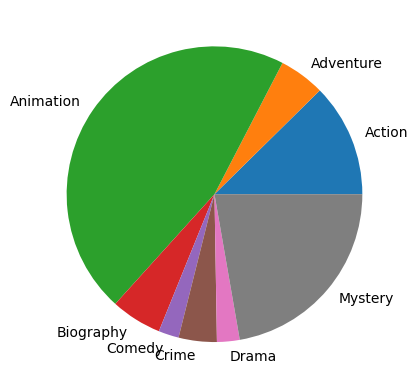

In [53]:
import matplotlib.pyplot as plt 

plt.pie(perc,labels=genre)

IMDB genre earning

Find out the percentage of the total earning for each genre in IMDB Movie Dataset?Plot the pie chart.
Print the genre and percentage of movies total earning present in that genre with 2 decimal place after rounding off.
Note: Movies has multiple genres, so calculate the percentage for each genre.Total Earning=Domestic earning + WorldWide earning.
Output Format:
genre_1 percent_1
genre_2 percent_2
. . .
. . .

In [61]:
data=pd.read_sql_query("select genre,Totalearning from Refined_dataset group by genre",db)
data.drop(0,inplace=True)
data

,genre,Totalearning
1,Action,368351006.0
2,Adventure,79074027.0
3,Animation,880346440.0
4,Biography,244405195.0
5,Comedy,74201975.0
6,Crime,111235855.0
7,Drama,26578984.0
8,Mystery,422817129.0


In [63]:
genre=data["genre"].values
earning=data["Totalearning"].values
nearning=np.array(earning)
total=data["Totalearning"].sum()
perc=(nearning/total)*100
for i in range(len(genre)):
    print(genre[i],format(perc[i],".2f"))

Action 16.69
Adventure 3.58
Animation 39.89
Biography 11.07
Comedy 3.36
Crime 5.04
Drama 1.20
Mystery 19.16


([<matplotlib.patches.Wedge at 0x22ea2fe1460>,
 [Text(0.9522238057081015, 0.5506993951719757, 'Action'),
  Text(0.4380377950188303, 1.0090207580298045, 'Adventure'),
  Text(-0.8986598630283111, 0.6343582982683661, 'Animation'),
  Text(-0.6068939424463287, -0.9174310560592291, 'Biography'),
  Text(-0.14358186618278185, -1.0905889453425932, 'Comedy'),
  Text(0.1459354964938954, -1.0902764928508184, 'Crime'),
  Text(0.3556510478580311, -1.0409189844351407, 'Drama'),
  Text(0.9067100018332128, -0.6227976979530475, 'Mystery')])

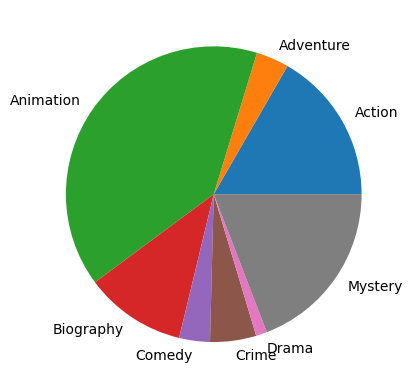

In [64]:
plt.pie(perc,labels=genre)

IMDB Specific Genre

Find the movie which has genre of 'Sci-Fi' and 'Mystery' and movie rating is greater or equal to 8 from IMDB Movie Database.
Print the movie name.
Movies has multiple genre.
Output Format:
movie_name

In [66]:
#updating refined table with rating 
usetable["Rating"]=table1["Rating"]
usetable

,Movie_id,Domestic,Worldwide,Title,Budget,Totalearning,Year,genre,Rating
0,36809,56671993,1.877332e+08,12 Years a Slave (2013),20000000.0,2.444052e+08,2013,Biography,8.1
1,30114,18335230,6.073880e+07,127 Hours (2010),18000000.0,7.907403e+07,2010,Adventure,7.6
2,37367,35014192,3.918778e+07,50/50 (2011),8000000.0,7.420198e+07,2011,Comedy,7.7
3,49473,15322921,8.710045e+07,About Time (2013),12000000.0,1.024234e+08,2013,Comedy,7.8
4,14867,6739492,1.983949e+07,Amour (2012),8900000.0,2.657898e+07,2012,Drama,7.9
...,...,...,...,...,...,...,...,...,...
112,38262,13092000,4.898204e+07,Whiplash (2014),3300000.0,6.207404e+07,2014,Drama,8.5
113,10023,189422889,4.712229e+08,Wreck-It Ralph (2012),165000000.0,6.606458e+08,2012,Animation,7.7
114,27783,233921534,7.478628e+08,X-Men: Days of Future Past (2014),200000000.0,9.817843e+08,2014,Action,8.0
115,42294,146408305,3.536241e+08,X-Men: First Class (2011),160000000.0,5.000324e+08,2011,Action,7.8


In [67]:
usetable.to_sql("Refined_dataset",db,if_exists="replace")

117

In [77]:
data=pd.read_sql_query("select Title from Refined_dataset where genre in('Sci-Fi','Mystery') and Rating>=8",db)
data

,Title
0,Shutter Island (2010)


In [78]:
import sqlite3

# Connect to the SQLite database
conn = db

# Define the SQL query to find the movie
query = """
    SELECT Title
    FROM IMDB
    JOIN genre ON IMDB.Movie_id = genre.movie_id
    WHERE genre.genre IN ('Sci-Fi', 'Mystery')
    AND IMDB.rating >= 8;
"""

# Execute the query
cursor = conn.execute(query)

# Fetch the result
result = cursor.fetchone()

# Close the database connection
conn.close()

# Check if a movie was found
if result:
    movie_name = result[0]
    print(movie_name)
else:
    print("No such movie found.")


Arrival (2016)
